# **Services Master CSV Notebook**
### **Author: Lauren Vo**
**Updated: Dec 16, 2025**

This notebook builds a single master dataset of youth-relevant **services/opportunities** from selected SANDAG GeoJSON layers, then attaches **Census Tract GEOIDs** (San Diego County) using TIGER/Line tracts.

**Inputs**
- `data/raw/sandag/*.geojson`
- `data/external/tiger_tracts_2023/tl_2023_06_tract.zip`

**Outputs**
- `data/processed/services/services_master.csv`
- `data/processed/services/services_master.geojson`

**Key data notes / assumptions**
- “Services” are defined by an allowlist of SANDAG layers (can evolve over time).
- Intentionally exclude broad “Places” style POI layers to avoid noise.
- Coordinate-based “duplicates” are reviewed carefully: co-located services (e.g., multiple schools on one campus) are not automatically removed.

**Current coverage summary**
- Tracts with 0 services: **52 / 737 (7.1%)**

In [68]:
from pathlib import Path
import os
import re
import json
import hashlib
import warnings

import numpy as np
import pandas as pd

# Geo stack 
try:
    import geopandas as gpd
    from shapely.geometry import Point
except ImportError as e:
    raise ImportError(
        "Missing geopandas stack. Install dependencies first (e.g., `pip install -r requirements.txt`).\n"
        f"Original error: {e}"
    )

warnings.filterwarnings("ignore", category=UserWarning)

In [69]:
# Project root detection
candidates = [
    Path("."),
    Path(".."),
    Path("../.."),
    Path("../../.."),
    Path("../../../.."),
]

PROJECT_ROOT = None
for cand in candidates:
    cand = cand.resolve()
    if (cand / "data" / "raw" / "sandag").exists() and (cand / "data" / "external" / "tiger_tracts_2023").exists():
        PROJECT_ROOT = cand
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find required directories from this notebook location:\n"
        "- data/raw/sandag\n"
        "- data/external/tiger_tracts_2023\n"
        "Move this notebook inside the Mapping-Youth-Opportunity-Deserts repo and try again."
    )

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
RAW_SANDAG_DIR = DATA_DIR / "raw" / "sandag"
EXTERNAL_TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"

INTERIM_SERVICES_DIR = DATA_DIR / "interim" / "services"
PROCESSED_SERVICES_DIR = DATA_DIR / "processed" / "services"
INTERIM_SERVICES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_SERVICES_DIR.mkdir(parents=True, exist_ok=True)

RAW_SANDAG_DIR, EXTERNAL_TIGER_DIR, PROCESSED_SERVICES_DIR

Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts


(PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/raw/sandag'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/external/tiger_tracts_2023'),
 PosixPath('/Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services'))

In [70]:
# Config: which SANDAG layers count as "services/opportunities"?
# Edit this allowlist as our definition of "youth services" evolves.
SANDAG_SERVICE_ALLOWLIST = {
    "Child_Care_Centers.geojson",
    "Colleges_SG.geojson",
    "Cool_Zones.geojson",
    "Healthcare_Facilities.geojson",
    "Hospitals.geojson",
    "Library.geojson",
    "Medication_Assisted_Treatment_Locations.geojson",
    "Naloxone_Vending_Machines.geojson",
    "Parks.geojson",
    # "Parks_CN.geojson",
    # "Parks_SD.geojson", redundant information
    # "Places.geojson", adds too much noise and irrelevant
    "Recreation_Centers_CN.geojson",
    "Recreation_Centers_SD.geojson",
    "Schools.geojson",
    # "School_Poly.geojson", redundant information
}

INCLUDE_ALL_SANDAG_FILES = False

# Output filenames
MASTER_CSV_PATH = PROCESSED_SERVICES_DIR / "services_master.csv"
MASTER_GEOJSON_PATH = PROCESSED_SERVICES_DIR / "services_master.geojson"

In [71]:
# Helpers
def slugify(s: str) -> str:
    s = str(s) if s is not None else ""
    s = s.strip().lower()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s

def stable_row_id(*parts: str) -> str:
    raw = "||".join([("" if p is None else str(p)) for p in parts])
    return hashlib.sha1(raw.encode("utf-8")).hexdigest()

def pick_first_existing_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def normalize_string(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    return s if s != "" else None

def coerce_wgs84(gdf: "gpd.GeoDataFrame") -> "gpd.GeoDataFrame":
    # Ensure CRS exists; GeoJSON is usually EPSG:4326 but sometimes it's missing.
    if gdf.crs is None:
        gdf = gdf.set_crs("EPSG:4326", allow_override=True)
    if str(gdf.crs).lower() not in ["epsg:4326", "wgs84"]:
        gdf = gdf.to_crs("EPSG:4326")
    return gdf

def geometry_to_point(geom):
    # If already point, keep. If polygon/line, use centroid (best-effort).
    if geom is None:
        return None
    gt = geom.geom_type
    if gt == "Point":
        return geom
    try:
        return geom.centroid
    except Exception:
        return None

def extract_lat_lon(gdf: "gpd.GeoDataFrame") -> "gpd.GeoDataFrame":
    gdf["geometry_point"] = gdf["geometry"].apply(geometry_to_point)
    gdf["lon"] = gdf["geometry_point"].apply(lambda p: p.x if p is not None else np.nan)
    gdf["lat"] = gdf["geometry_point"].apply(lambda p: p.y if p is not None else np.nan)
    # Use point geometry as the canonical geometry for mapping + spatial joins
    gdf = gdf.drop(columns=["geometry"])
    gdf = gdf.rename(columns={"geometry_point": "geometry"})
    gdf = gpd.GeoDataFrame(gdf, geometry="geometry", crs="EPSG:4326")
    return gdf

def standardize_service_fields(gdf: "gpd.GeoDataFrame", source_file: str) -> "gpd.GeoDataFrame":
    # Keep a copy of raw properties (everything but geometry) for traceability.
    non_geom_cols = [c for c in gdf.columns if c != "geometry"]
    gdf["raw_properties_json"] = gdf[non_geom_cols].apply(lambda r: json.dumps(r.to_dict(), default=str), axis=1)

    # Common naming patterns across civic POI datasets
    name_col = pick_first_existing_col(
        gdf,
        ["name", "Name", "NAME", "facility", "FACILITY", "site_name", "SiteName", "PLACE_NAME", "PlaceName"]
    )
    addr_col = pick_first_existing_col(
        gdf,
        ["address", "Address", "ADDRESS", "street", "STREET", "addr", "ADDR", "fulladdr", "FULLADDR"]
    )
    city_col = pick_first_existing_col(gdf, ["city", "City", "CITY"])
    zip_col = pick_first_existing_col(gdf, ["zip", "Zip", "ZIP", "zipcode", "ZipCode", "POSTCODE", "postcode"])
    phone_col = pick_first_existing_col(gdf, ["phone", "Phone", "PHONE", "telephone", "TELEPHONE"])
    web_col = pick_first_existing_col(gdf, ["website", "Website", "WEB", "url", "URL", "link", "LINK"])

    # Standard fields
    gdf["source"] = "SANDAG"
    gdf["source_file"] = source_file
    gdf["category"] = source_file.replace(".geojson", "")
    gdf["category_slug"] = gdf["category"].map(slugify)

    gdf["name"] = gdf[name_col].map(normalize_string) if name_col else None
    gdf["address"] = gdf[addr_col].map(normalize_string) if addr_col else None
    gdf["city"] = gdf[city_col].map(normalize_string) if city_col else None
    gdf["zip"] = gdf[zip_col].map(normalize_string) if zip_col else None
    gdf["phone"] = gdf[phone_col].map(normalize_string) if phone_col else None
    gdf["website"] = gdf[web_col].map(normalize_string) if web_col else None

    # Build a stable service_id for dedupe/joins later
    # Prefer name+address; else name+lat/lon; else fallback to file+row index later.
    gdf["service_id"] = gdf.apply(
        lambda r: stable_row_id(
            r.get("source"),
            r.get("category"),
            r.get("name"),
            r.get("address"),
            round(r.get("lat"), 6) if pd.notna(r.get("lat")) else None,
            round(r.get("lon"), 6) if pd.notna(r.get("lon")) else None,
        ),
        axis=1
    )

    return gdf

In [72]:
# Load SANDAG service layers
all_geojson_files = sorted([p for p in RAW_SANDAG_DIR.glob("*.geojson")])

if INCLUDE_ALL_SANDAG_FILES:
    chosen_files = all_geojson_files
else:
    chosen_files = [p for p in all_geojson_files if p.name in SANDAG_SERVICE_ALLOWLIST]

print("Found GeoJSON files in sandag/:", len(all_geojson_files))
print("Using files:", len(chosen_files))
for p in chosen_files:
    print(" -", p.name)

service_layers = []

for path in chosen_files:
    layer_name = path.name
    gdf = gpd.read_file(path)

    # Normalize CRS to WGS84 for consistent lat/lon and spatial join
    gdf = coerce_wgs84(gdf)

    # Reduce to point geometry + extract lat/lon
    gdf = extract_lat_lon(gdf)

    # Drop rows with missing coords (can't map or tract-join)
    gdf = gdf[pd.notna(gdf["lat"]) & pd.notna(gdf["lon"])].copy()

    # Standardize fields
    gdf = standardize_service_fields(gdf, source_file=layer_name)

    # Keep
    service_layers.append(gdf)

if len(service_layers) == 0:
    raise RuntimeError("No service layers loaded. Check RAW_SANDAG_DIR and your allowlist.")

services_gdf = gpd.GeoDataFrame(pd.concat(service_layers, ignore_index=True), geometry="geometry", crs="EPSG:4326")
print("Total raw service rows:", len(services_gdf))

# Quick quality check
services_gdf[["category", "name", "address", "lat", "lon"]].head(10)


Found GeoJSON files in sandag/: 22
Using files: 12
 - Child_Care_Centers.geojson
 - Colleges_SG.geojson
 - Cool_Zones.geojson
 - Healthcare_Facilities.geojson
 - Hospitals.geojson
 - Library.geojson
 - Medication_Assisted_Treatment_Locations.geojson
 - Naloxone_Vending_Machines.geojson
 - Parks.geojson
 - Recreation_Centers_CN.geojson
 - Recreation_Centers_SD.geojson
 - Schools.geojson
Total raw service rows: 6526


,category,name,address,lat,lon
0,Child_Care_Centers,None,None,32.676800,-117.061001
1,Child_Care_Centers,None,None,32.736128,-117.047621
2,Child_Care_Centers,None,None,32.737497,-117.031554
3,Child_Care_Centers,None,None,32.622239,-117.059138
4,Child_Care_Centers,None,None,32.698235,-117.172105
5,Child_Care_Centers,None,None,32.854551,-116.606038
6,Child_Care_Centers,None,None,32.799544,-117.000338
7,Child_Care_Centers,None,None,32.745919,-117.164648
8,Child_Care_Centers,None,None,32.752503,-116.960916
9,Child_Care_Centers,None,None,32.753906,-117.176130


In [73]:
# Deduplication 
# Strategy:
# - Exact duplicate service_id collapses to 1 record.
# - Additionally, collapse perfect duplicates on (category, name, address, rounded lat/lon).
services_gdf["lat_round5"] = services_gdf["lat"].round(5)
services_gdf["lon_round5"] = services_gdf["lon"].round(5)

before = len(services_gdf)
services_gdf = services_gdf.drop_duplicates(subset=["service_id"]).copy()

services_gdf = services_gdf.drop_duplicates(
    subset=["category", "name", "address", "lat_round5", "lon_round5"]
).copy()

after = len(services_gdf)
print(f"Deduped: {before} -> {after} rows")

Deduped: 6526 -> 5905 rows


In [74]:
# Load TIGER/Line Census Tracts (California) and filter to San Diego County
TRACT_ZIP = EXTERNAL_TIGER_DIR / "tl_2023_06_tract.zip"
if not TRACT_ZIP.exists():
    raise FileNotFoundError(f"Missing tract zip: {TRACT_ZIP}")

tracts = gpd.read_file(TRACT_ZIP)

# TIGER tracts typically come in NAD83 (EPSG:4269); convert to WGS84 for sjoin consistency.
tracts = tracts.set_crs(tracts.crs or "EPSG:4269", allow_override=True).to_crs("EPSG:4326")

# Filter to San Diego County: STATEFP=06 (CA), COUNTYFP=073 (San Diego)
# Keep only the minimal columns we need.
needed_cols = [c for c in ["GEOID", "NAME", "NAMELSAD", "STATEFP", "COUNTYFP", "TRACTCE"] if c in tracts.columns]
tracts = tracts[needed_cols + ["geometry"]].copy()

tracts_sd = tracts[(tracts["STATEFP"] == "06") & (tracts["COUNTYFP"] == "073")].copy()
if len(tracts_sd) == 0:
    raise RuntimeError("San Diego tract filter returned 0 rows. Inspect tract fields in tl_2023_06_tract.zip.")

print("San Diego tracts:", len(tracts_sd))
tracts_sd.head(3)

San Diego tracts: 737


,GEOID,NAME,NAMELSAD,STATEFP,COUNTYFP,TRACTCE,geometry
810,06073008331,83.31,Census Tract 83.31,06,073,008331,"POLYGON ((-117.23082 32.94176, -117.23079 32.9..."
819,06073008336,83.36,Census Tract 83.36,06,073,008336,"POLYGON ((-117.13793 32.96927, -117.13792 32.9..."
820,06073008337,83.37,Census Tract 83.37,06,073,008337,"POLYGON ((-117.14678 32.95497, -117.14657 32.9..."


In [75]:
# Spatial join: attach tract GEOID to each service point
services_joined = gpd.sjoin(
    services_gdf,
    tracts_sd.rename(columns={"GEOID": "tract_geoid", "NAME": "tract_name", "NAMELSAD": "tract_namelsad"}),
    how="left",
    predicate="within"
)

# gpd.sjoin adds index_right; drop it
if "index_right" in services_joined.columns:
    services_joined = services_joined.drop(columns=["index_right"])

# Flag whether a service point landed in an SD tract
services_joined["in_sd_tract"] = services_joined["tract_geoid"].notna()

missing_tract = services_joined["tract_geoid"].isna().sum()
print("Services with missing tract_geoid:", int(missing_tract), "out of", len(services_joined))


Services with missing tract_geoid: 313 out of 5905


In [76]:
missing = services_joined[services_joined["tract_geoid"].isna()].copy()

print("Missing tract_geoid:", len(missing), "out of", len(services_joined))
print("\nMissing by category:")
print(missing["category"].value_counts())

print("\nExample missing rows (lat/lon/category):")
cols = [c for c in ["category", "name", "lat", "lon", "address", "city"] if c in missing.columns]
display(missing[cols].head(20))

Missing tract_geoid: 313 out of 5905

Missing by category:
category
Healthcare_Facilities    279
Hospitals                 32
Parks                      2
Name: count, dtype: int64

Example missing rows (lat/lon/category):


,category,name,lat,lon,address,city
1784,Healthcare_Facilities,None,32.781098,-115.567657,None,None
1785,Healthcare_Facilities,None,32.958944,-115.553689,None,None
1786,Healthcare_Facilities,None,33.651790,-117.911798,None,None
1787,Healthcare_Facilities,None,33.624732,-117.929730,None,None
1788,Healthcare_Facilities,None,33.711067,-117.884019,None,None
1789,Healthcare_Facilities,None,33.561001,-117.665359,None,None
1790,Healthcare_Facilities,None,33.609320,-117.708918,None,None
1791,Healthcare_Facilities,None,33.500252,-117.741930,None,None
1792,Healthcare_Facilities,None,33.730112,-117.828475,None,None
1793,Healthcare_Facilities,None,33.660676,-117.772297,None,None


In [77]:
services_joined = gpd.sjoin(
    services_gdf,
    tracts_sd.rename(columns={"GEOID": "tract_geoid", "NAME": "tract_name", "NAMELSAD": "tract_namelsad"}),
    how="left",
    predicate="within"
).drop(columns=["index_right"], errors="ignore")

services_joined["in_sd_tract"] = services_joined["tract_geoid"].notna()

# Keep ONLY San Diego County services for the master output
services_final = services_joined[services_joined["in_sd_tract"]].copy()

print("Dropped out-of-county:", (~services_joined["in_sd_tract"]).sum())
print("Final SD-only services:", len(services_final))


Dropped out-of-county: 313
Final SD-only services: 5592


In [78]:
print("Missing tract_geoid in final:", services_final["tract_geoid"].isna().sum())
print(services_final["category"].value_counts())

Missing tract_geoid in final: 0
category
Parks                                      2685
Child_Care_Centers                         1081
Schools                                    1001
Healthcare_Facilities                       423
Library                                      92
Cool_Zones                                   85
Colleges_SG                                  78
Recreation_Centers_SD                        61
Medication_Assisted_Treatment_Locations      34
Hospitals                                    33
Naloxone_Vending_Machines                    12
Recreation_Centers_CN                         7
Name: count, dtype: int64


In [79]:
print("Total rows:", len(services_final))

exact_dups = services_final.duplicated(keep="first").sum()
print("Exact duplicate rows:", exact_dups)

# Drop them
services_final = services_final.drop_duplicates().copy()
print("After dropping exact duplicates:", len(services_final))

Total rows: 5592
Exact duplicate rows: 0
After dropping exact duplicates: 5592


In [80]:
key_cols = ["category", "lat", "lon"]

dup_rows = (
    services_final[services_final.duplicated(subset=key_cols, keep=False)]
    .sort_values(key_cols)
    .copy()
)

print("Duplicate rows (all occurrences):", len(dup_rows))

show_cols = key_cols + [c for c in ["name","address","city","zip","website","phone","tract_geoid","source_file"] if c in services_final.columns]
display(dup_rows[show_cols])

Duplicate rows (all occurrences): 95


,category,lat,lon,name,address,city,zip,website,phone,tract_geoid,source_file
2728,Medication_Assisted_Treatment_Locations,32.566196,-117.060099,Precision Park Behavioral Health,"1666 Precision Park Lane, San Ysidro, CA 92173",None,None,https://www.syhealth.org/clinics/precision-par...,None,06073010005,Medication_Assisted_Treatment_Locations.geojson
2729,Medication_Assisted_Treatment_Locations,32.566196,-117.060099,Precision Park Behavioral Health,"1666 Precision Park Ln, San Ysidro, CA 92173",None,None,https://www.syhealth.org/clinics/precision-par...,None,06073010005,Medication_Assisted_Treatment_Locations.geojson
2747,Medication_Assisted_Treatment_Locations,32.784820,-116.977002,San Ysidro Health Clinic at El Cajon,"875 El Cajon Blvd, El Cajon, CA 92020",None,None,https://www.syhealth.org/clinics/san-ysidro-he...,None,06073015902,Medication_Assisted_Treatment_Locations.geojson
2756,Medication_Assisted_Treatment_Locations,32.784820,-116.977002,El Cajon Clinic,"875 El Cajon Boulevard, El Cajon, CA 92020",None,None,https://www.syhealth.org/clinics/san-ysidro-he...,None,06073015902,Medication_Assisted_Treatment_Locations.geojson
5327,Parks,32.699751,-117.171243,Coronado Ferry Landing Park,None,None,None,None,None,06073011000,Parks.geojson
...,...,...,...,...,...,...,...,...,...,...,...
6461,Schools,33.278352,-116.954242,All Tribes Charter,34320 Valley Center Road,Valley Center,92082-6046,None,None,06073019110,Schools.geojson
6480,Schools,33.296606,-117.174449,Bonsall High,7350 West Lilac Road,Bonsall,92003-4316,None,None,06073018803,Schools.geojson
6482,Schools,33.296606,-117.174449,Norman L. Sullivan Middle,7350 West Lilac Road,Bonsall,92003-5112,None,None,06073018803,Schools.geojson
5909,Schools,33.379820,-117.255226,Maie Ellis Elementary,400 West Elder Street,Fallbrook,92028-2108,None,None,06073018904,Schools.geojson


In [81]:
DUP_CSV = PROCESSED_SERVICES_DIR / "duplicates_by_category_lat_lon.csv"
dup_rows[show_cols].to_csv(DUP_CSV, index=False)
print("Wrote:", DUP_CSV)

Wrote: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services/duplicates_by_category_lat_lon.csv


In [82]:
# Final column selection + export
# Keep a clean set of columns plus raw JSON for traceability.
final_cols = [
    "service_id",
    "source",
    "source_file",
    "category",
    "category_slug",
    "name",
    "address",
    "city",
    "zip",
    "phone",
    "website",
    "lat",
    "lon",
    "tract_geoid",
    "tract_name",
    "tract_namelsad",
    "raw_properties_json",
    "geometry",
]
final_cols = [c for c in final_cols if c in services_joined.columns]

final_gdf = services_joined[final_cols].copy()

# Geometry → WKT for CSV (so CSV stays portable)
final_df = pd.DataFrame(final_gdf.drop(columns=["geometry"]))
final_df["geometry_wkt"] = final_gdf["geometry"].apply(lambda g: g.wkt if g is not None else None)

# Write outputs
final_df.to_csv(MASTER_CSV_PATH, index=False)
final_gdf.to_file(MASTER_GEOJSON_PATH, driver="GeoJSON")

print("Wrote CSV:", MASTER_CSV_PATH)
print("Wrote GeoJSON:", MASTER_GEOJSON_PATH)

Wrote CSV: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services/services_master.csv
Wrote GeoJSON: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services/services_master.geojson


In [83]:
# Duplicate checks + dedupe (safe)
import re

def _norm_text(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^a-z0-9 ]+", "", x)  # remove punctuation
    return x

def _norm_url(x):
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = re.sub(r"^https?://", "", x)
    x = re.sub(r"^www\.", "", x)
    x = x.split("?")[0].rstrip("/")
    return x

# Create normalized helpers 
final_df = final_df.copy()
final_df["name_norm"] = final_df["name"].apply(_norm_text) if "name" in final_df.columns else ""
final_df["website_norm"] = final_df["website"].apply(_norm_url) if "website" in final_df.columns else ""

# Stabilize float noise 
final_df["lat_r"] = final_df["lat"].astype(float).round(6)
final_df["lon_r"] = final_df["lon"].astype(float).round(6)

# Prefer the “most complete” record when duplicates exist
prefer_cols = [c for c in ["name", "address", "city", "zip", "website", "phone"] if c in final_df.columns]
def _completeness_score(row):
    s = 0
    for c in prefer_cols:
        v = row.get(c)
        if pd.notna(v) and str(v).strip() != "":
            s += 1
    addr = str(row.get("address") or "")
    s += min(len(addr), 80) / 1000.0  # small tie-breaker
    return s

final_df["_score"] = final_df.apply(_completeness_score, axis=1)

# PASS 1: same category + same name (normalized) + same point
key_1 = ["category", "name_norm", "lat_r", "lon_r"]
dups_1 = int(final_df.duplicated(subset=key_1, keep="first").sum())
print(f"\nDuplicates (same category + name + point): {dups_1}")

# Show examples (all rows in duplicate groups)
if dups_1 > 0:
    dup_rows_1 = final_df[final_df.duplicated(subset=key_1, keep=False)].sort_values(key_1)
    display(dup_rows_1[[c for c in ["category","name","address","city","zip","website","phone","lat","lon","tract_geoid","source_file"] if c in final_df.columns]].head(50))

# Dedupe (keep best score)
before = len(final_df)
final_df = final_df.sort_values("_score", ascending=False).drop_duplicates(subset=key_1, keep="first").copy()
print(f"After dedupe pass 1: {len(final_df)} rows (dropped {before - len(final_df)})")

# PASS 2: same category + same website (normalized) + same point (only if website exists)
if "website_norm" in final_df.columns:
    key_2 = ["category", "website_norm", "lat_r", "lon_r"]
    dups_2 = int(final_df.duplicated(subset=key_2, keep="first").sum())
    print(f"\nDuplicates (same category + website + point): {dups_2}")

    if dups_2 > 0:
        dup_rows_2 = final_df[final_df.duplicated(subset=key_2, keep=False)].sort_values(key_2)
        display(dup_rows_2[[c for c in ["category","name","address","city","zip","website","phone","lat","lon","tract_geoid","source_file"] if c in final_df.columns]].head(50))

    before2 = len(final_df)
    final_df = final_df.sort_values("_score", ascending=False).drop_duplicates(subset=key_2, keep="first").copy()
    print(f"After dedupe pass 2: {len(final_df)} rows (dropped {before2 - len(final_df)})")

# Cleanup helper columns
final_df = final_df.drop(columns=["name_norm","website_norm","lat_r","lon_r","_score"], errors="ignore")

# Sanity summaries 
print("\nCounts by category:")
display(final_df["category"].value_counts().to_frame("count"))

print("\nMissing coordinates (should be 0):")
display(pd.DataFrame({
    "missing_lat": [int(final_df["lat"].isna().sum())],
    "missing_lon": [int(final_df["lon"].isna().sum())],
}))

print("\nMissing tract_geoid:")
display(pd.DataFrame({
    "missing_tract_geoid": [int(final_df["tract_geoid"].isna().sum())],
    "total": [len(final_df)],
    "pct_missing": [float(final_df["tract_geoid"].isna().mean())],
}))

# Peek at final rows
final_df.head(20)


Duplicates (same category + name + point): 1


,category,name,address,city,zip,website,phone,lat,lon,tract_geoid,source_file
2728,Medication_Assisted_Treatment_Locations,Precision Park Behavioral Health,"1666 Precision Park Lane, San Ysidro, CA 92173",None,None,https://www.syhealth.org/clinics/precision-par...,None,32.566196,-117.060099,06073010005,Medication_Assisted_Treatment_Locations.geojson
2729,Medication_Assisted_Treatment_Locations,Precision Park Behavioral Health,"1666 Precision Park Ln, San Ysidro, CA 92173",None,None,https://www.syhealth.org/clinics/precision-par...,None,32.566196,-117.060099,06073010005,Medication_Assisted_Treatment_Locations.geojson


After dedupe pass 1: 5904 rows (dropped 1)

Duplicates (same category + website + point): 52


,category,name,address,city,zip,website,phone,lat,lon,tract_geoid,source_file
2756,Medication_Assisted_Treatment_Locations,El Cajon Clinic,"875 El Cajon Boulevard, El Cajon, CA 92020",None,None,https://www.syhealth.org/clinics/san-ysidro-he...,None,32.784820,-116.977002,06073015902,Medication_Assisted_Treatment_Locations.geojson
2747,Medication_Assisted_Treatment_Locations,San Ysidro Health Clinic at El Cajon,"875 El Cajon Blvd, El Cajon, CA 92020",None,None,https://www.syhealth.org/clinics/san-ysidro-he...,None,32.784820,-116.977002,06073015902,Medication_Assisted_Treatment_Locations.geojson
5327,Parks,Coronado Ferry Landing Park,None,None,None,None,None,32.699751,-117.171243,06073011000,Parks.geojson
5328,Parks,Centennial Park,None,None,None,None,None,32.699751,-117.171243,06073011000,Parks.geojson
5461,Recreation_Centers_CN,Spring Valley Gymnasium,None,Spring Valley,91977,None,619-667-6833,32.712381,-117.001701,06073013908,Recreation_Centers_CN.geojson
5457,Recreation_Centers_CN,SpringValley REC Club,None,Spring Valley,91977,None,619-667-6835,32.712381,-117.001701,06073013908,Recreation_Centers_CN.geojson
6321,Schools,SBUSD Virtual Academy,490 Emory Street,Imperial Beach,91932-1101,None,None,32.588266,-117.113589,06073010502,Schools.geojson
6323,Schools,Bayside STEAM Academy,490 Emory Street,Imperial Beach,91932-1524,None,None,32.588266,-117.113589,06073010502,Schools.geojson
6472,Schools,High Tech Middle Chula Vista,1949 Discovery Falls Drive,Chula Vista,91915-2037,None,None,32.616330,-116.954587,06073013319,Schools.geojson
6473,Schools,High Tech Elementary Chula Vista,1949 Discovery Falls Drive,Chula Vista,91915-2037,None,None,32.616330,-116.954587,06073013319,Schools.geojson


After dedupe pass 2: 5852 rows (dropped 52)

Counts by category:


...


Missing coordinates (should be 0):


,missing_lat,missing_lon
0,0,0



Missing tract_geoid:


,missing_tract_geoid,total,pct_missing
0,313,5852,0.053486


,service_id,source,source_file,category,category_slug,name,address,city,zip,phone,website,lat,lon,tract_geoid,tract_name,tract_namelsad,raw_properties_json,geometry_wkt
2679,2d6b88b392fce650cfe0b970105fd67fb4892149,SANDAG,Library.geojson,Library,library,24/7 Library To Go - County Operations Center,"5560 Overland Avenue, Ste 110","San Diego, CA",92123,(858) 694-2415,None,32.833463,-117.130323,06073008511,85.11,Census Tract 85.11,"{""OBJECTID"": 49, ""WEBSITE"": ""https://www.sdcl....",POINT (-117.13032265532163 32.83346313639715)
2708,b9698b1ec7724bb5290ea2fd2db4443d2eba999e,SANDAG,Library.geojson,Library,library,Santee Branch,9225 Carlton Hills Blvd. #17,"Santee, CA",92071,(619) 448-1863,None,32.844668,-116.996935,06073016614,166.14,Census Tract 166.14,"{""OBJECTID"": 78, ""WEBSITE"": ""https://www.sdcl....",POINT (-116.99693543983233 32.84466794373619)
2689,01edd8f689ce2f4b74bb6c130ece59a2d5710895,SANDAG,Library.geojson,Library,library,Del Mar Branch,"1309 Camino Del Mar, Del Mar","Del Mar, CA",92014,(858) 755-1666,None,32.957766,-117.264345,06073017202,172.02,Census Tract 172.02,"{""OBJECTID"": 59, ""WEBSITE"": ""https://www.sdcl....",POINT (-117.26434479873133 32.95776586065226)
2658,3245e024c43336bf4bb4b0b93387e37fbedafa70,SANDAG,Library.geojson,Library,library,Rancho Bernardo,17110 Bernardo Center Drive,"San Diego, CA",92128,(858) 538-8163,None,33.024937,-117.074920,06073017058,170.58,Census Tract 170.58,"{""OBJECTID"": 28, ""WEBSITE"": ""http://www.sandie...",POINT (-117.07492025468216 33.02493675072204)
2705,47d073c84bb3554a29c2340c44ee8d06b7a253ee,SANDAG,Library.geojson,Library,library,Rancho San Diego Branch,11555 Via Rancho San Diego,"El Cajon, CA",92019,(619) 660-5370,None,32.749249,-116.929052,06073013608,136.08,Census Tract 136.08,"{""OBJECTID"": 75, ""WEBSITE"": ""https://www.sdcl....",POINT (-116.9290519723824 32.749248751515836)
2676,8bafc9bffd7dca62e6cb76305bd0d9f113a472a6,SANDAG,Library.geojson,Library,library,Otay Ranch Branch,"2015 Birch Road, Suite 409","Chula Vista, CA",91915,(619) 397-5740,None,32.622833,-116.969279,06073013319,133.19,Census Tract 133.19,"{""OBJECTID"": 46, ""WEBSITE"": ""https://www.chula...",POINT (-116.96927879766723 32.62283332625857)
2638,1c11a06535731fe7e566f0daceba8efbf51490ff,SANDAG,Library.geojson,Library,library,Balboa,4255 Mt. Abernathy Avenue,"San Diego, CA",92117,(858) 573-1390,None,32.822432,-117.174902,06073008507,85.07,Census Tract 85.07,"{""OBJECTID"": 8, ""WEBSITE"": ""http://www.sandieg...",POINT (-117.17490204857161 32.8224315136091)
2706,46f1ff06e9e4c64553dbc15ecd0d2aef3409796d,SANDAG,Library.geojson,Library,library,Rancho Santa Fe Branch,17040 Avenida de Acacias,"Rancho Santa Fe, CA",92067,(858) 756-2512,None,33.020976,-117.205525,06073017106,171.06,Census Tract 171.06,"{""OBJECTID"": 76, ""WEBSITE"": ""https://www.sdcl....",POINT (-117.20552499362937 33.02097591592826)
2654,871d9866248daa4b7619fa1d3ce5dd70f21ea5c1,SANDAG,Library.geojson,Library,library,Ocean Beach,4801 Santa Monica Avenue,"San Diego, CA",92107,(619) 531-1532,None,32.745448,-117.247263,06073007502,75.02,Census Tract 75.02,"{""OBJECTID"": 24, ""WEBSITE"": ""http://www.sandie...",POINT (-117.24726338422454 32.74544782535878)
2694,d0e0a51357b3b64d8dddedc4636a7b584a892288,SANDAG,Library.geojson,Library,library,Imperial Beach Branch,810 Imperial Beach Blvd.,"Imperial Beach, CA",91932,(619) 424-6981,None,32.576928,-117.116237,06073010300,103,Census Tract 103,"{""OBJECTID"": 64, ""WEBSITE"": ""https://www.sdcl....",POINT (-117.11623700114728 32.57692816792801)


## **Visualize Services (Points + Heatmap + Tract Choropleth)**

**Inputs:**
- data/processed/services/services_master.geojson  (preferred)
- data/external/tiger_tracts_2023/tl_2023_06_tract.zip

**Output:**
- data/processed/services/services_map.html

In [89]:
from pathlib import Path
import warnings

import pandas as pd
import geopandas as gpd

warnings.filterwarnings("ignore", category=UserWarning)

try:
    import folium
    from folium.plugins import MarkerCluster, HeatMap
    from branca.colormap import StepColormap
except ImportError as e:
    raise ImportError(
        "Missing folium/branca. Install it with:\n"
        "  pip install folium branca\n"
        f"Original error: {e}"
    )

# Project root detection
candidates = [
    Path("."),
    Path(".."),
    Path("../.."),
    Path("../../.."),
    Path("../../../.."),
]

PROJECT_ROOT = None
for cand in candidates:
    cand = cand.resolve()
    if (cand / "data" / "processed" / "services").exists() and (cand / "data" / "external" / "tiger_tracts_2023").exists():
        PROJECT_ROOT = cand
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find required directories from this notebook location:\n"
        "- data/processed/services\n"
        "- data/external/tiger_tracts_2023\n"
        "Move this notebook inside the Mapping-Youth-Opportunity-Deserts repo and try again."
    )

print("Using PROJECT_ROOT:", PROJECT_ROOT)

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_SERVICES_DIR = DATA_DIR / "processed" / "services"
EXTERNAL_TIGER_DIR = DATA_DIR / "external" / "tiger_tracts_2023"

SERVICES_GEOJSON = PROCESSED_SERVICES_DIR / "services_master.geojson"
TRACT_ZIP = EXTERNAL_TIGER_DIR / "tl_2023_06_tract.zip"

OUTPUT_HTML = PROCESSED_SERVICES_DIR / "services_map.html"

SERVICES_GEOJSON, TRACT_ZIP

# Load services (GeoJSON)
if not SERVICES_GEOJSON.exists():
    raise FileNotFoundError(f"Missing: {SERVICES_GEOJSON}. Run the services master builder notebook first.")

services = gpd.read_file(SERVICES_GEOJSON)

# Ensure WGS84
if services.crs is None:
    services = services.set_crs("EPSG:4326", allow_override=True)
else:
    services = services.to_crs("EPSG:4326")

# Basic sanity checks
required = ["lat", "lon", "category"]
missing = [c for c in required if c not in services.columns]
if missing:
    raise ValueError(f"services_master.geojson missing required columns: {missing}")

services = services[pd.notna(services["lat"]) & pd.notna(services["lon"])].copy()
print("Services rows:", len(services))
services.head(3)

# Load tracts (San Diego County)
if not TRACT_ZIP.exists():
    raise FileNotFoundError(f"Missing: {TRACT_ZIP}")

tracts = gpd.read_file(TRACT_ZIP)

# TIGER often comes as EPSG:4269; convert to 4326
tracts = tracts.set_crs(tracts.crs or "EPSG:4269", allow_override=True).to_crs("EPSG:4326")

# Filter: CA (06), San Diego County (073)
if not {"STATEFP", "COUNTYFP", "GEOID"}.issubset(set(tracts.columns)):
    raise ValueError("Tracts file missing expected TIGER columns (STATEFP, COUNTYFP, GEOID).")

tracts_sd = tracts[(tracts["STATEFP"] == "06") & (tracts["COUNTYFP"] == "073")].copy()

# Keep only what we need
keep_cols = [c for c in ["GEOID", "NAME", "NAMELSAD"] if c in tracts_sd.columns] + ["geometry"]
tracts_sd = tracts_sd[keep_cols].rename(columns={"GEOID": "tract_geoid"})
print("San Diego tracts:", len(tracts_sd))
tracts_sd.head(2)

# Enforce SD-only points for mapping (fixes stray out-of-county points in HTML)
if "tract_geoid" in services.columns:
    before = len(services)
    services = services[services["tract_geoid"].notna()].copy()
    print(f"Filtered to SD tracts using tract_geoid: {before} -> {len(services)}")
else:
    print("WARNING: services has no tract_geoid; cannot filter SD-only here.")

# Helper: map center
center_lat = float(services["lat"].median())
center_lon = float(services["lon"].median())

m = folium.Map(location=[center_lat, center_lon], zoom_start=10, control_scale=True)

# Layer 1: Points (clustered), grouped by category
cluster = MarkerCluster(name="Services (clustered points)", show=True)
cluster.add_to(m)

# Keep popups small + safe for performance
popup_cols = [c for c in ["name", "category", "address", "city", "zip", "phone", "website", "tract_geoid"] if c in services.columns]

for _, row in services.iterrows():
    lat = float(row["lat"])
    lon = float(row["lon"])

    # Build a simple HTML popup
    lines = []
    for c in popup_cols:
        val = row.get(c)
        if pd.notna(val) and str(val).strip() != "":
            lines.append(f"<b>{c}</b>: {str(val)}")
    html = "<br>".join(lines) if lines else "Service"

    folium.CircleMarker(
        location=[lat, lon],
        radius=4,
        fill=True,
        fill_opacity=0.7,
        popup=folium.Popup(html, max_width=350),
    ).add_to(cluster)

# Layer 2: Heatmap
heat_data = services[["lat", "lon"]].astype(float).values.tolist()
HeatMap(heat_data, name="Heatmap", show=False).add_to(m)

# Layer 3: Choropleth (services per tract) — FIXED BINS + VISIBLE TOGGLE
if "tract_geoid" not in services.columns:
    print("WARNING: services does not have tract_geoid. Choropleth will be skipped.")
else:
    counts = (
        services.dropna(subset=["tract_geoid"])
        .groupby("tract_geoid")
        .size()
        .reset_index(name="service_count")
    )

    tracts_sd_counts = tracts_sd.merge(counts, on="tract_geoid", how="left")
    tracts_sd_counts["service_count"] = tracts_sd_counts["service_count"].fillna(0).astype(int)

    # Your discrete bins: 0, 1–2, 3–5, 6–10, 11–25, 26+
    from branca.colormap import StepColormap

    max_count = int(tracts_sd_counts["service_count"].max())
    thresholds = [0, 1, 3, 6, 11, 26, max_count + 1]

    colors = ["#eff3ff", "#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]

    colormap = StepColormap(
        colors=colors,
        index=thresholds,
        vmin=0,
        vmax=max_count,
        caption="Services per Census Tract (binned: 0, 1–2, 3–5, 6–10, 11–25, 26+)"
    )

    def _style(feat):
        v = feat["properties"].get("service_count", None)
        try:
            v = float(v) if v is not None else None
        except Exception:
            v = None
        return {
            "fillColor": colormap(v) if v is not None else "#dddddd",
            "color": "white",
            "weight": 0.2,
            "fillOpacity": 0.75,
        }

    folium.GeoJson(
        tracts_sd_counts,
        name="Choropleth: services per tract",
        style_function=_style,
        highlight_function=lambda x: {"weight": 1.5},
        show=False,   # starts off, but will toggle correctly
    ).add_to(m)

    colormap.add_to(m)

    # Tooltip boundaries layer (separate)
    tooltip_fields = ["tract_geoid", "service_count"]
    if "NAME" in tracts_sd_counts.columns:
        tooltip_fields.insert(1, "NAME")
    if "NAMELSAD" in tracts_sd_counts.columns:
        tooltip_fields.insert(1, "NAMELSAD")

    folium.GeoJson(
        tracts_sd_counts,
        name="Tract boundaries (tooltip)",
        style_function=lambda x: {"fillOpacity": 0, "weight": 0.4, "color": "#333333"},
        tooltip=folium.features.GeoJsonTooltip(
            fields=[f for f in tooltip_fields if f in tracts_sd_counts.columns],
            aliases=[f"{f}: " for f in tooltip_fields if f in tracts_sd_counts.columns],
            sticky=False
        ),
        show=False
    ).add_to(m)

# Controls
folium.LayerControl(collapsed=False).add_to(m)

# Display map in notebook
m

# Save map as HTML for GitHub / sharing
m.save(str(OUTPUT_HTML))
print("Saved:", OUTPUT_HTML)

Using PROJECT_ROOT: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts
Services rows: 5905
San Diego tracts: 737
Filtered to SD tracts using tract_geoid: 5905 -> 5592
Saved: /Users/laurenvo/Documents/github/Mapping-Youth-Opportunity-Deserts/data/processed/services/services_map.html


## **Visualizations**

### 1) Choropleth: **Services per Census Tract (San Diego County)**
This map shows how service locations concentrate unevenly across the county. A small number of tracts have very high counts (dense clusters), while many tracts have relatively few. This helps identify where services are geographically concentrated versus sparse.

**Gap signal:** tracts with **0 services** are flagged as immediate coverage gaps for follow-up (data completeness vs true lack of services).

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_22705/3148847689.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


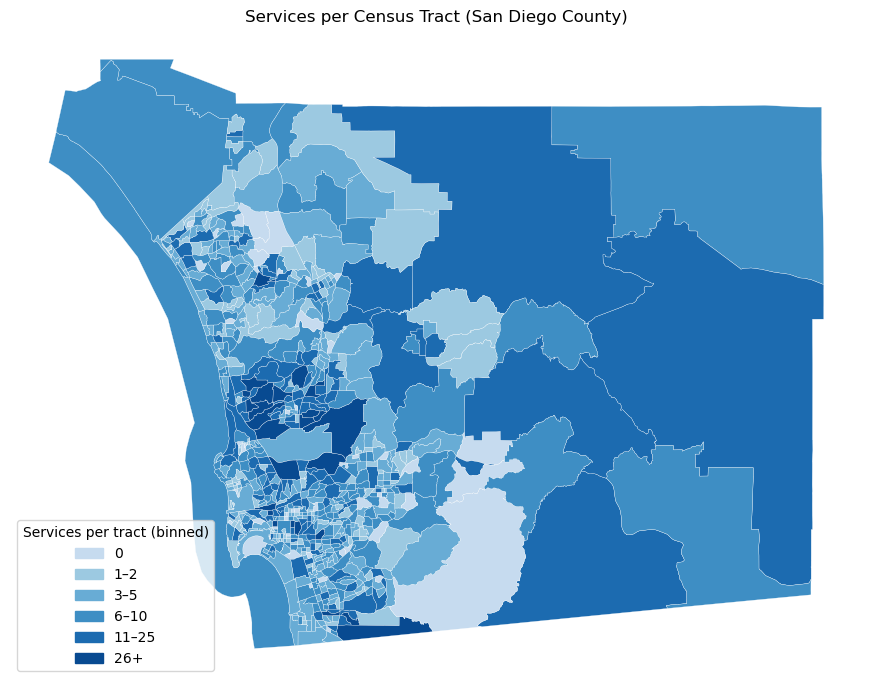

Tracts with 0 services: 52/737 (7.1%)


In [85]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import pandas as pd

# Count services per tract
counts = (
    services.dropna(subset=["tract_geoid"])
    .groupby("tract_geoid")
    .size()
    .reset_index(name="service_count")
)

tracts_counts = tracts_sd.merge(counts, on="tract_geoid", how="left")
tracts_counts["service_count"] = tracts_counts["service_count"].fillna(0).astype(int)

# Discrete bins (same as yours)
bins = [-1, 0, 2, 5, 10, 25, tracts_counts["service_count"].max()]
labels = ["0", "1–2", "3–5", "6–10", "11–25", "26+"]

tracts_counts["service_bin"] = pd.cut(
    tracts_counts["service_count"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

def _blue_gradient(n, start=0.25, end=0.90):
    cmap = cm.get_cmap("Blues")
    xs = np.linspace(start, end, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

blue_colors = _blue_gradient(len(labels))

# Map each bin -> a blue shade (low = light, high = dark)
bin_colors = {lab: blue_colors[i] for i, lab in enumerate(labels)}
tracts_counts["plot_color"] = tracts_counts["service_bin"].astype(str).map(bin_colors).fillna("lightgrey")

# Plot
fig, ax = plt.subplots(figsize=(11, 11))
tracts_counts.plot(
    ax=ax,
    color=tracts_counts["plot_color"],
    linewidth=0.2,
    edgecolor="white"
)

ax.set_title("Services per Census Tract (San Diego County)")
ax.set_axis_off()

handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
ax.legend(
    handles=handles,
    title="Services per tract (binned)",
    loc="lower left",
    frameon=True
)

plt.show()

# Quick numeric summary
zero = int((tracts_counts["service_count"] == 0).sum())
total = len(tracts_counts)
print(f"Tracts with 0 services: {zero}/{total} ({zero/total:.1%})")


### 2) Histogram: **Distribution of Services per Tract**
The distribution is strongly right-skewed: most tracts have low-to-moderate counts, and a small number of tracts are extreme high-count outliers. This indicates that “average services per tract” is not very representative, and medians/percentiles are more useful.

### 3) Bar chart: **Tracts by Coverage Bucket**
Buckets (0, 1–2, 3–5, 6–10, 11+) summarize coverage in a way that’s easier to communicate to stakeholders. This highlights how many tracts fall into “low coverage” vs “high coverage” categories.


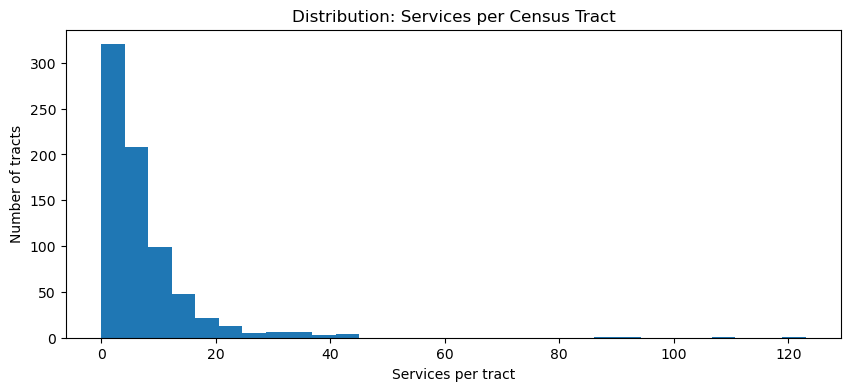

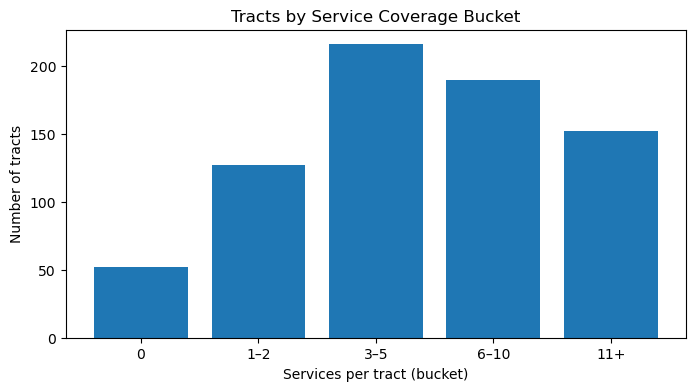

In [86]:
svc = tracts_counts["service_count"].values

# Histogram
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(svc, bins=30)
ax.set_title("Distribution: Services per Census Tract")
ax.set_xlabel("Services per tract")
ax.set_ylabel("Number of tracts")
plt.show()

# Bucketed view 
bins = [-1, 0, 2, 5, 10, 999999]
labels = ["0", "1–2", "3–5", "6–10", "11+"]
bucket = pd.cut(tracts_counts["service_count"], bins=bins, labels=labels)
bucket_counts = bucket.value_counts().reindex(labels, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(bucket_counts.index.astype(str), bucket_counts.values)
ax.set_title("Tracts by Service Coverage Bucket")
ax.set_xlabel("Services per tract (bucket)")
ax.set_ylabel("Number of tracts")
plt.show()

### 4) Map: **Distance to Nearest Service (centroid-based) + worst-case table**
This estimates accessibility by tract: for each tract centroid, compute the distance to the nearest service point. Larger values indicate tracts where residents likely travel farther to reach any listed service/opportunity.

**Important caveat:** centroid distance is a proxy (not network travel time). Rural/large tracts can look worse due to size.

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_22705/133800355.py:50: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


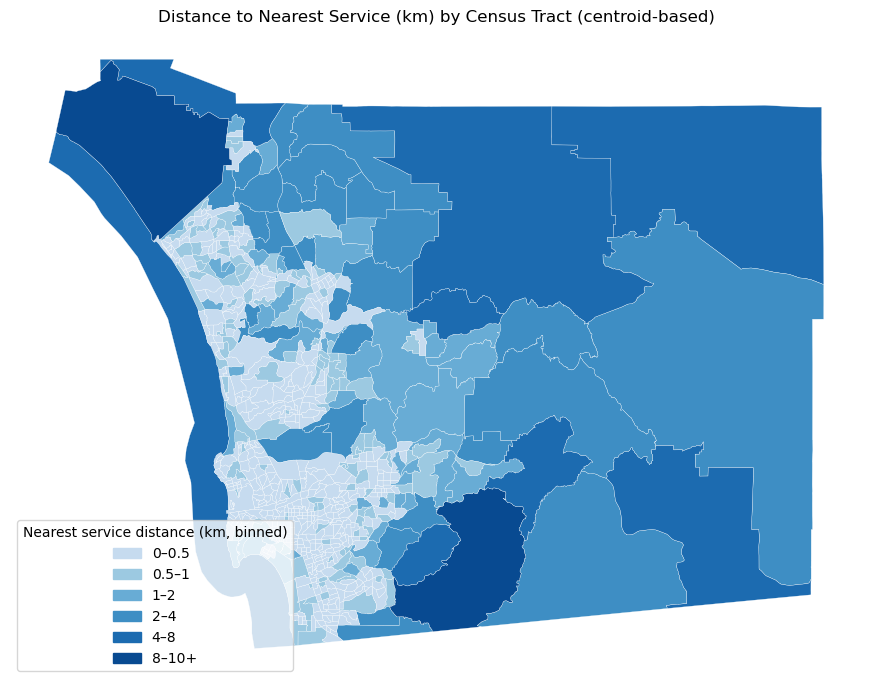

,tract_geoid,service_count,nearest_km
373,06073021302,0,9.827206
409,06073018700,10,8.969635
199,06073021102,6,7.813477
324,06073019001,8,7.045567
287,06073990100,6,6.635997
150,06073021002,9,6.133264
377,06073020903,16,4.730677
476,06073020807,1,4.415433
685,06073021202,7,4.304101
559,06073021304,5,4.171472


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import geopandas as gpd

# Use a projected CRS for distance (meters). EPSG:3310 = California Albers.
services_proj = services.to_crs("EPSG:3310")
tracts_proj = tracts_counts.to_crs("EPSG:3310")

# Centroids for each tract
tract_centroids = tracts_proj.copy()
tract_centroids["geometry"] = tract_centroids.geometry.centroid

# Nearest service distance per tract centroid
if hasattr(gpd, "sjoin_nearest"):
    nearest = gpd.sjoin_nearest(
        tract_centroids[["tract_geoid", "geometry"]],
        services_proj[["service_id", "geometry"]],
        how="left",
        distance_col="nearest_m"
    )
    tract_dist = tracts_counts.merge(
        nearest[["tract_geoid", "nearest_m"]],
        on="tract_geoid",
        how="left"
    )
else:
    raise RuntimeError("geopandas.sjoin_nearest not available in your geopandas version. Upgrade geopandas.")

tract_dist["nearest_km"] = (tract_dist["nearest_m"] / 1000.0).replace([np.inf, -np.inf], np.nan)

# Discrete bins (same as yours)
dmax = float(np.nanmax(tract_dist["nearest_km"])) if tract_dist["nearest_km"].notna().any() else 0.0
bins = [0, 0.5, 1, 2, 4, 8, max(10, np.ceil(dmax))]
labels = ["0–0.5", "0.5–1", "1–2", "2–4", "4–8", f"8–{int(max(10, np.ceil(dmax)))}+"]

tract_dist["dist_bin"] = pd.cut(
    tract_dist["nearest_km"].fillna(0),
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=True
)

# Blue gradient colors (low distance = light, high distance = dark)
def _blue_gradient(n, start=0.25, end=0.90):
    cmap = cm.get_cmap("Blues")
    xs = np.linspace(start, end, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

blue_colors = _blue_gradient(len(labels))
bin_colors = {lab: blue_colors[i] for i, lab in enumerate(labels)}

tract_dist["plot_color"] = tract_dist["dist_bin"].astype(str).map(bin_colors).fillna("lightgrey")

# Map: tracts far from services 
fig, ax = plt.subplots(figsize=(11, 11))
tract_dist.plot(
    ax=ax,
    color=tract_dist["plot_color"],
    linewidth=0.2,
    edgecolor="white"
)
ax.set_title("Distance to Nearest Service (km) by Census Tract (centroid-based)")
ax.set_axis_off()

handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
ax.legend(
    handles=handles,
    title="Nearest service distance (km, binned)",
    loc="lower left",
    frameon=True
)

plt.show()

# Show worst gaps (top 15 farthest tracts)
display(
    tract_dist[["tract_geoid", "service_count", "nearest_km"]]
    .sort_values("nearest_km", ascending=False)
    .head(15)
)


### 5) Map: **Category Diversity per Tract (unique service types)**
This shows whether a tract has a mix of different service categories or is dominated by one type. Low diversity can indicate areas where youth may have limited choices even if there are some services present.

/var/folders/dg/bllrnyzj2fzf93_myxywvnnm0000gn/T/ipykernel_22705/2321584505.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("Blues")


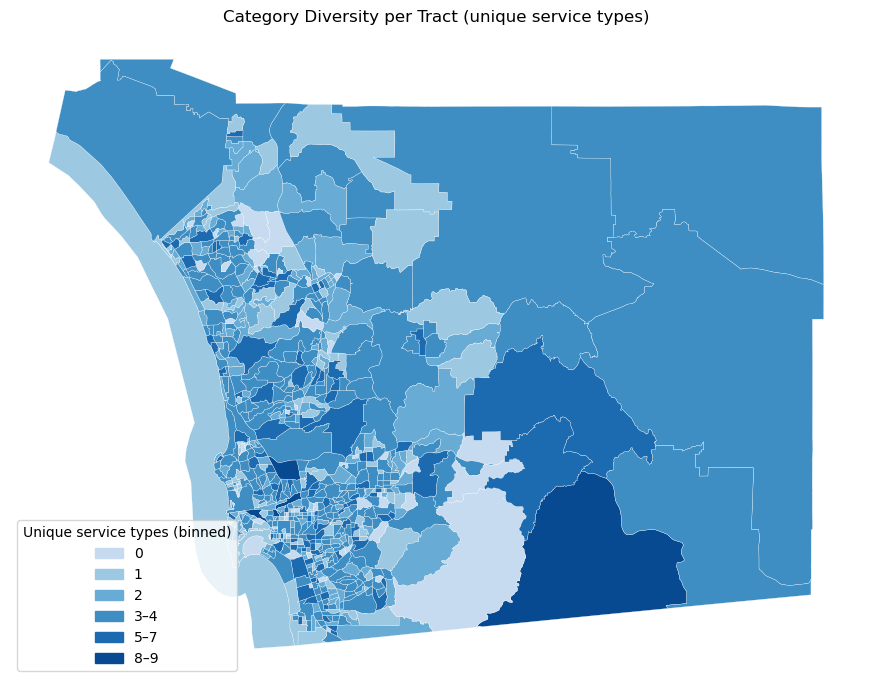

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors

cat_div = (
    services.dropna(subset=["tract_geoid"])
    .groupby("tract_geoid")["category"]
    .nunique()
    .reset_index(name="category_diversity")
)

tract_div = tracts_counts.merge(cat_div, on="tract_geoid", how="left")
tract_div["category_diversity"] = tract_div["category_diversity"].fillna(0).astype(int)

# Bins (same as yours)
dmax = int(tract_div["category_diversity"].max())
bins = [0, 1, 2, 3, 5, 8, max(10, dmax + 1)]
labels = ["0", "1", "2", "3–4", "5–7", f"8–{max(9, dmax)}"]

tract_div["div_bin"] = pd.cut(
    tract_div["category_diversity"],
    bins=bins,
    labels=labels,
    include_lowest=True,
    right=False
)

# ----------------------------
# Blue gradient colors (low diversity = light, high diversity = dark)
# ----------------------------
def _blue_gradient(n, start=0.25, end=0.90):
    cmap = cm.get_cmap("Blues")
    xs = np.linspace(start, end, n)
    return [mcolors.to_hex(cmap(x)) for x in xs]

blue_colors = _blue_gradient(len(labels))
bin_colors = {lab: blue_colors[i] for i, lab in enumerate(labels)}

tract_div["plot_color"] = tract_div["div_bin"].astype(str).map(bin_colors).fillna("lightgrey")

# Map: category diversity 
fig, ax = plt.subplots(figsize=(11, 11))
tract_div.plot(
    ax=ax,
    color=tract_div["plot_color"],
    linewidth=0.2,
    edgecolor="white"
)
ax.set_title("Category Diversity per Tract (unique service types)")
ax.set_axis_off()

handles = [mpatches.Patch(color=bin_colors[l], label=l) for l in labels]
ax.legend(
    handles=handles,
    title="Unique service types (binned)",
    loc="lower left",
    frameon=True
)

plt.show()
